Starting the plant disease classification process using Vision Transformer...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
Loading data...
Found 32572 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Found 10885 images belonging to 38 classes.
Creating ViT model...
Starting training...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 219s 182ms/step - accuracy: 0.1308 - loss: 3.3297 - val_accuracy: 0.2889 - val_loss: 2.4489 - learning_rate: 0.0010
Epoch 2/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.2620 - loss: 2.6095 - val_accuracy: 0.4345 - val_loss: 1.9743 - learning_rate: 0.0010
Epoch 3/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 201s 160ms/step - accuracy: 0.3644 - loss: 2.1973 - val_accuracy: 0.5300 - val_loss: 1.6149 - learning_rate: 0.0010
Epoch 4/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 170s 167ms/step - accuracy: 0.4564 - loss: 1.8495 - val_accuracy: 0.6225 - val_loss: 1.3005 - learning_rate: 0.0010
Epoch 5/5
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 167s 164ms/step - accuracy: 0.5372 - loss: 1.5801 - val_accuracy: 0.6981 - val_loss: 1.0718 - learning_rate: 0.0010
Evaluating on test set...
341/341 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.6464 - loss: 1.1948
Test accuracy: 0.6888


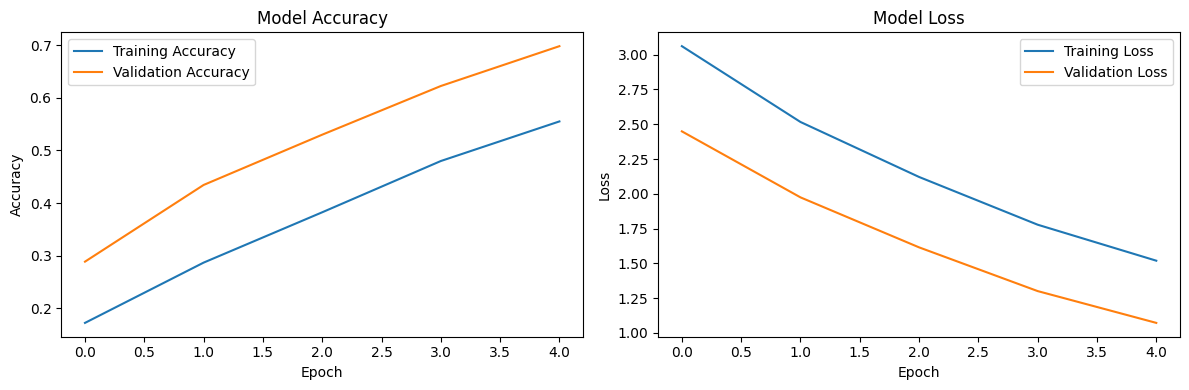

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
from sklearn.metrics import precision_recall_curve, auc

# Enable mixed precision training for faster execution
tf.keras.mixed_precision.set_global_policy('mixed_float16')

class PatchExtractor(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

def create_vit_model(
    input_shape=(128, 128, 3),
    patch_size=16,
    num_patches=64,
    projection_dim=64,
    num_transformer_blocks=4,
    num_heads=4,
    transformer_units=[128, 64],
    mlp_head_units=[256, 128],
    num_classes=38
):
    inputs = layers.Input(shape=input_shape)

    # Create patches and project them
    patches = PatchExtractor(patch_size)(inputs)
    projected_patches = layers.Dense(projection_dim)(patches)

    # Add position embeddings
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = layers.Embedding(
        input_dim=num_patches, output_dim=projection_dim
    )(positions)
    encoded_patches = projected_patches + position_embedding

    # Create transformer blocks
    for _ in range(num_transformer_blocks):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)

        # MLP
        x3 = layers.Dense(transformer_units[0], activation="gelu")(x3)
        x3 = layers.Dropout(0.1)(x3)
        x3 = layers.Dense(transformer_units[1], activation="gelu")(x3)
        x3 = layers.Dropout(0.1)(x3)

        encoded_patches = layers.Add()([x3, x2])

    # Create classification head
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)

    # MLP head
    features = layers.Dense(mlp_head_units[0], activation="gelu")(representation)
    features = layers.Dropout(0.3)(features)
    features = layers.Dense(mlp_head_units[1], activation="gelu")(features)
    features = layers.Dropout(0.3)(features)

    # Final classification layer
    logits = layers.Dense(num_classes, activation="softmax")(features)

    return Model(inputs=inputs, outputs=logits)

def load_data(base_path, img_size=(128, 128)):
    data_generator = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        fill_mode="nearest"
    )

    train_generator = data_generator.flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'train'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=True
    )

    val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'val'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(base_path, 'PLANT_VILLAGE_SPLIT', 'test'),
        target_size=img_size,
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_generator, val_generator, test_generator

def train_and_evaluate():
    # Mount Drive and extract dataset
    drive.mount('/content/drive')
    zip_path = "/content/drive/MyDrive/Copy of PLANT_VILLAGE_SPLIT.zip"
    extract_path = "/content/plant_village"

    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    # Load data
    print("Loading data...")
    train_generator, val_generator, test_generator = load_data(extract_path)
    num_classes = len(train_generator.class_indices)

    # Create and compile model
    print("Creating ViT model...")
    model = create_vit_model(num_classes=num_classes)

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=0.001,
        weight_decay=0.0001
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Add callbacks for early stopping and reduced training time
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=1
        )
    ]

    # Train with fewer epochs
    print("Starting training...")
    history = model.fit(
        train_generator,
        epochs=5,  # Reduced number of epochs
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # Quick evaluation
    print("Evaluating on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return (history.history['accuracy'][-1],
            history.history['val_accuracy'][-1],
            test_accuracy)

if __name__ == "__main__":
    print("Starting the plant disease classification process using Vision Transformer...")
    train_acc, val_acc, test_acc = train_and_evaluate()
    print(f"\nFinal Accuracies:")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")